# 无规行走


In [13]:
from manim import *

Manim Community v0.18.1

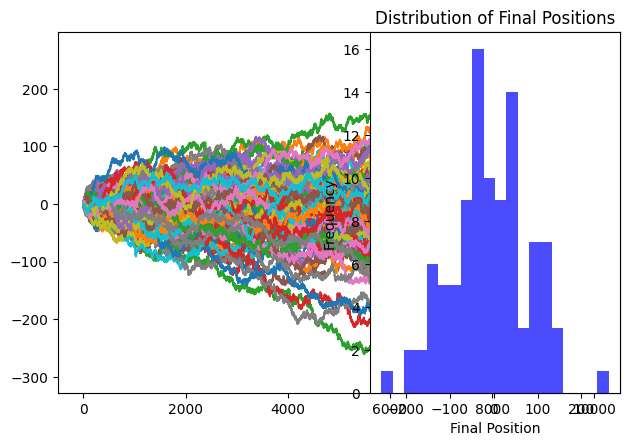

KeyboardInterrupt: 

In [22]:

%%manim -qm -v WARNING RandomWalkScene
import numpy as np
import matplotlib.pyplot as plt


class RandomWalk1D:
    def __init__(self, p_right=0.5):
        self.p_right = p_right
        self.position = 0

    def single_steps(self, steps):
        postion_history = [self.position]
        import random
        for _ in range(steps):
            if random.random() < self.p_right:
                self.position += 1
            else:
                self.position -= 1
            postion_history.append(self.position)
        return postion_history
    
    def batch_simulate(self, num_walkers, steps):
        all_histories = []
        for _ in range(num_walkers):
            self.position = 0  # Reset position for each walker
            history = self.single_steps(steps)
            all_histories.append(history)
        return np.array(all_histories)
    

    def plot_walks(self, walks):    
        for walk in walks:
            plt.plot(walk)
        
        subplot = plt.subplot(1, 2, 2)
        
        plt.xlabel('Steps')
        plt.ylabel('Position')
        plt.title('1D Random Walks')
        plt.grid()

        plt.hist(walks[:, -1], bins=20, alpha=0.7, color='blue')
        plt.xlabel('Final Position')
        plt.ylabel('Frequency')
        plt.title('Distribution of Final Positions')
        plt.grid()
        plt.tight_layout()
        plt.show()

class RandomWalkScene(Scene):
    def construct(self):
        rw = RandomWalk1D(p_right=0.5)
        num_walkers = 100
        steps = 10000
        walks = rw.batch_simulate(num_walkers, steps)
        dot1 = Dot(color=RED).shift(LEFT * 3)
        rw.plot_walks(walks)
        self.add(dot1)
        for i in range(steps):
            new_position = walks[0][i]
            dot1.move_to(LEFT * 3 + RIGHT * new_position)
            
            self.wait(0.1)
            self.play(Transform(dot1, dot1.copy().shift(RIGHT * 0.1)), run_time=0.1)


       











